In [1]:

import warnings
warnings.filterwarnings("ignore")

import gc
import joblib
from datetime import date, datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna

# Sklearn — model selection
from sklearn.model_selection import train_test_split, StratifiedKFold

# Sklearn — pipeline e preprocessamento
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import VarianceThreshold

# Sklearn — métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)

# Sklearn — modelos
from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble      import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection    import permutation_importance

# Modelos externos
import lightgbm as lgb
from lightgbm  import LGBMClassifier
from xgboost   import XGBClassifier
from catboost  import CatBoostClassifier

# Encoders
from category_encoders import TargetEncoder
import json

pd.set_option('display.float_format', '{:.4f}'.format)

hoje = date.today()

In [2]:
#Base de treino:
#C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Intermediarios\01train_bureau.parquet
#C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Intermediarios\02train_installments.parquet
#C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Intermediarios\03tain_creditcard.parquet
#C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Intermediarios\04train_poscash.parquet
#C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Intermediarios\05train_previous.parquet


#Base de teste:
#C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Intermediarios\01test_bureau.parquet
#C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Intermediarios\02test_installments.parquet
#C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Intermediarios\03test_creditcard.parquet
#C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Intermediarios\04test_poscash.parquet
#C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Intermediarios\05test_previous.parquet

### Importando Book -> Tirando Mau na Origem e Target missing

In [3]:
df_treino = pd.read_parquet(r'C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Intermediarios\01train_bureau.parquet')
df_treino = df_treino[~df_treino['TARGET'].isna()]

df_teste = pd.read_parquet(r'C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Intermediarios\01test_bureau.parquet')

In [4]:
RUNNING_IMPORTANCE = True
RUNNING_TUNNING = True

Importância de Variáveis

In [5]:
X = df_treino.drop(columns=['SK_ID_CURR','TARGET'])
y = df_treino['TARGET']

In [6]:
# 1- Remover variáveis com baixa variância

def remove_low_variance(X, threshold=0.01):
    X_num = X.select_dtypes(exclude='object')
    X_num_filled = X_num.fillna(X_num.median())  # VarianceThreshold não aceita NaN

    # Normaliza antes de checar variância, sem isso, o threshold absoluto
    # favorece colunas de escala grande (monetárias) e penaliza colunas de
    # escala pequena (razões, flags), independente do quanto elas variam de verdade
    scaler = StandardScaler()
    X_num_scaled = scaler.fit_transform(X_num_filled)

    selector = VarianceThreshold(threshold=threshold)
    selector.fit(X_num_scaled)  # descarta o output escalado — só queremos saber QUAIS colunas passam

    cols_selected = X_num.columns[selector.get_support()]
    return cols_selected


# 2- IV e KS univariados

def calcular_iv_ks(X, y, coluna, n_bins=10, min_amostra=500):
    '''Calcula IV (via WOE por bins) e KS univariado de uma variável numérica.
    Colunas com menos de min_amostra linhas não-nulas retornam NaN: com poucas
    amostras o qcut gera bins quase puros (só 0 ou só 1 de target) e o WOE
    explode pra valores absurdos de IV — é ruído de amostra pequena, não
    sinal real.'''
    dados = pd.DataFrame({'var': X[coluna], 'target': y}).dropna()
    pct_missing = round(X[coluna].isnull().mean() * 100, 2)

    if len(dados) < min_amostra or dados['target'].nunique() < 2:
        return {'variavel': coluna, 'iv': np.nan, 'ks': np.nan, 'pct_missing': pct_missing}

    try:
        dados['bin'] = pd.qcut(dados['var'], q=n_bins, duplicates='drop')
    except ValueError:
        return {'variavel': coluna, 'iv': np.nan, 'ks': np.nan, 'pct_missing': pct_missing}

    grp = dados.groupby('bin', observed=True)['target'].agg(['count', 'sum'])
    grp['bom'] = grp['count'] - grp['sum']
    grp['mau'] = grp['sum']
    total_bom = grp['bom'].sum()
    total_mau = grp['mau'].sum()

    grp['pct_bom'] = grp['bom'] / total_bom
    grp['pct_mau'] = grp['mau'] / total_mau
    grp['woe'] = np.log((grp['pct_bom'].replace(0, 1e-6)) / (grp['pct_mau'].replace(0, 1e-6)))
    grp['iv_bin'] = (grp['pct_bom'] - grp['pct_mau']) * grp['woe']
    iv = grp['iv_bin'].sum()

    grp_sorted = grp.sort_index()
    ks = (grp_sorted['pct_bom'].cumsum() - grp_sorted['pct_mau'].cumsum()).abs().max()

    return {
        'variavel': coluna,
        'iv': round(iv, 4),
        'ks': round(ks, 4),
        'pct_missing': pct_missing
    }


def iv_ks_filter(X, y, cols, iv_min=0.02, n_bins=10, min_amostra=500):
    '''Roda IV/KS para uma lista de colunas numéricas e filtra pelo IV mínimo.'''
    resultados = [calcular_iv_ks(X, y, c, n_bins=n_bins, min_amostra=min_amostra) for c in cols]
    df_iv = pd.DataFrame(resultados).sort_values('iv', ascending=False).reset_index(drop=True)
    cols_aprovadas = df_iv.loc[df_iv['iv'] >= iv_min, 'variavel'].tolist()
    return df_iv, cols_aprovadas


# 3- Correlação entre variáveis numéricas

def correlation_filter(X, threshold=0.90):

    X_num       = X.select_dtypes(include=np.number)
    corr_matrix = X_num.corr().abs()
    upper       = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    remove      = [column for column in upper.columns if any(upper[column] > threshold)]
    return remove


# 4- Feature importance LightGBM

def lgbm_feature_importance(X_train, y_train, cat_cols=None):
    X_fit = X_train.copy()
    if cat_cols:
        for c in cat_cols:
            X_fit[c] = X_fit[c].astype('category')

    model = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
        verbose=-1
    )
    model.fit(X_fit, y_train, categorical_feature=cat_cols if cat_cols else 'auto')
    importance = pd.DataFrame({
        "variavel"  : X_fit.columns,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False).reset_index(drop=True)
    return importance


# 5- Rodar seleção
#e o split é só um holdout estratificado simples

X_sel = X
y_sel = y

# Split ANTES da seleção — importância calculada só no treino
X_sel_train, X_sel_test, y_sel_train, _ = train_test_split(
    X_sel, y_sel, test_size=0.30, stratify=y_sel, random_state=42
)

print("Shape inicial:", X_sel_train.shape)

cat_cols_sel = X_sel_train.select_dtypes(include='object').columns.tolist()
print("Colunas categóricas identificadas:", len(cat_cols_sel))

# Baixa variância fit no treino
cols_lowvar = remove_low_variance(X_sel_train, threshold=0.01)
print("\nApós baixa variância:", len(cols_lowvar))

# IV/KS fit no treino
df_iv, cols_iv_aprovadas = iv_ks_filter(X_sel_train, y_sel_train, cols_lowvar, iv_min=0.02)
print("Após filtro de IV (>= 0.02):", len(cols_iv_aprovadas))
print(df_iv.head(15))

# Correlação fit no treino — só entre as já aprovadas por IV
cols_iv_ordenadas = df_iv[df_iv['variavel'].isin(cols_iv_aprovadas)].sort_values('iv', ascending=False)['variavel'].tolist()
corr_remove = correlation_filter(X_sel_train[cols_iv_ordenadas], threshold=0.90)
print("\nVariáveis removidas por correlação:", len(corr_remove))

cols_finais_num = [c for c in cols_iv_aprovadas if c not in corr_remove]
cols_finais = cols_finais_num + cat_cols_sel

X_final_train = X_sel_train[cols_finais]
print("Shape final após filtros:", X_final_train.shape)

# Importância LightGBM - (astype category + categorical_feature)
importance = lgbm_feature_importance(X_final_train, y_sel_train, cat_cols=cat_cols_sel)
importance

Shape inicial: (215257, 1220)
Colunas categóricas identificadas: 16

Após baixa variância: 947
Após filtro de IV (>= 0.02): 215
                              variavel     iv     ks  pct_missing
0                         EXT_SOURCE_3 0.3972 0.2643      19.8000
1      BUR_MEAN_DAYS_CREDIT_ENDDATE_U9 0.3809 0.2110      99.7100
2                         EXT_SOURCE_1 0.3431 0.2387      56.4100
3       BUR_MIN_DAYS_CREDIT_ENDDATE_U9 0.3395 0.2223      99.7100
4       BUR_MAX_DAYS_CREDIT_ENDDATE_U9 0.3388 0.2110      99.7100
5    BUR_MEDIAN_DAYS_CREDIT_ENDDATE_U9 0.3350 0.2223      99.7100
6                         EXT_SOURCE_2 0.3108 0.2228       0.2200
7            BUR_SUM_AMT_CREDIT_SUM_U9 0.3002 0.1914      99.6400
8            BUR_MIN_AMT_CREDIT_SUM_U9 0.2678 0.2140      99.6400
9           BUR_MEAN_AMT_CREDIT_SUM_U9 0.2510 0.2095      99.6400
10           BUR_MAX_AMT_CREDIT_SUM_U9 0.2504 0.2021      99.6400
11        BUR_MEDIAN_AMT_CREDIT_SUM_U9 0.2486 0.2083      99.6400
12          BU

,variavel,importance
0,ORGANIZATION_TYPE,329
1,EXT_SOURCE_1,189
2,EXT_SOURCE_3,166
3,EXT_SOURCE_2,152
4,AMT_GOODS_PRICE,127
...,...,...
63,BUR_SUM_QTD_FLAG_STATUS_1_FLAG_ULTIMOS_12_MESES,0
64,BUR_ACELERACAO_AMT_CREDIT_SUM_DEBT_U18_U24_vs_...,0
65,NAME_TYPE_SUITE,0
66,FLAG_OWN_CAR,0


Salvando Lista das Top Variáveis

In [9]:
if RUNNING_IMPORTANCE:
    file_path_vars = r'C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Modelo\Variaveis\vars_selecionadas-01-Bureau.json'

    importance = importance[importance['importance'] > 0]
    vars = importance['variavel'].to_list()
    vars = vars[:50]
    print(f"{len(vars)} variáveis salvas em: {file_path_vars}")

    with open(file_path_vars, 'w', encoding='utf-8') as f:
        json.dump(vars, f, ensure_ascii=False, indent=2)


else:
    file_path_vars = r'C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Modelo\Variaveis\vars_selecionadas-01-Bureau.json'

    with open(file_path_vars, 'r', encoding='utf-8') as f:
        vars = json.load(f)

    print(f"{len(vars)} variáveis carregadas.")
    print(vars[:5])

50 variáveis salvas em: C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Modelo\Variaveis\vars_selecionadas-01-Bureau.json


## Parte 1 — Preparando os dados (sem treinar ainda)

In [10]:
# ATENÇÃO: aqui só preparamos os dados (split + imputação + encoding).

COLS_TIRAR_TREINO = ['SK_ID_CURR', 'TARGET']
cols_remover_treino = [c for c in COLS_TIRAR_TREINO if c in df_treino.columns]

X = df_treino.drop(columns=cols_remover_treino)
y = df_treino['TARGET']

X = X[vars]

# Base oficial de teste da Home Credit — guarda o SK_ID_CURR à parte,
# ele não entra no modelo mas é obrigatório na submissão final.
ids_teste = df_teste['SK_ID_CURR'].copy()
X_teste = df_teste[vars].copy()  # mesmas colunas selecionadas

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=0
)

# Guarda os SK_ID_CURR do holdout e do treino, alinhados por índice — vai
ids_train = df_treino.loc[X_train.index, 'SK_ID_CURR'].values
ids_test  = df_treino.loc[X_test.index,  'SK_ID_CURR'].values

# ======================================================
# Identificação das colunas
# ======================================================

cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]

# ======================================================
# Missing numéricos
# NÃO imputamos os numéricos para os modelos de árvore que tratam NaN
# ======================================================

medians = X_train[num_cols].median()

X_train_imp = X_train.copy()
X_test_imp  = X_test.copy()
X_teste_imp = X_teste.copy()

X_train_imp[num_cols] = X_train_imp[num_cols].fillna(medians)
X_test_imp[num_cols]  = X_test_imp[num_cols].fillna(medians)
X_teste_imp[num_cols] = X_teste_imp[num_cols].fillna(medians)

# ======================================================
# Missing categóricos — preenchidos com a moda em todas as versões
# ======================================================

mode = X_train[cat_cols].mode().iloc[0]

for _df in (X_train, X_test, X_teste, X_train_imp, X_test_imp, X_teste_imp):
    _df[cat_cols] = _df[cat_cols].fillna(mode)

def target_encode_oof(X_train, y_train, X_test, X_teste, cat_cols, n_splits=5, random_state=0, **encoder_kwargs):
    X_train_enc = X_train.copy()
    oof_cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    oof_values = pd.DataFrame(index=X_train.index, columns=cat_cols, dtype=float)

    for tr_idx, val_idx in oof_cv.split(X_train, y_train):
        fold_encoder = TargetEncoder(cols=cat_cols, **encoder_kwargs)
        fold_encoder.fit(X_train.iloc[tr_idx][cat_cols], y_train.iloc[tr_idx])
        transformado = fold_encoder.transform(X_train.iloc[val_idx][cat_cols])
        oof_values.iloc[val_idx] = transformado.values

    X_train_enc[cat_cols] = oof_values

    encoder_final = TargetEncoder(cols=cat_cols, **encoder_kwargs)
    encoder_final.fit(X_train[cat_cols], y_train)

    X_test_enc  = X_test.copy()
    X_teste_enc = X_teste.copy()
    X_test_enc[cat_cols]  = encoder_final.transform(X_test[cat_cols])
    X_teste_enc[cat_cols] = encoder_final.transform(X_teste[cat_cols])

    return X_train_enc, X_test_enc, X_teste_enc, encoder_final


X_train, X_test, X_teste, encoder = target_encode_oof(
    X_train, y_train, X_test, X_teste, cat_cols
)
X_train_imp, X_test_imp, X_teste_imp, encoder_imp = target_encode_oof(
    X_train_imp, y_train, X_test_imp, X_teste_imp, cat_cols
)

print("X_train:", X_train.shape, "| X_test:", X_test.shape, "| X_teste (Kaggle):", X_teste.shape)
print("Missing em X_train (modelos de árvore):", X_train.isna().sum().sum(), "células")

# ======================================================
# Padronização — só usada pela LogisticRegression
# ======================================================

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=X_train_imp.columns, index=X_train_imp.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test_imp),  columns=X_test_imp.columns,  index=X_test_imp.index)
X_teste_scaled = pd.DataFrame(scaler.transform(X_teste_imp), columns=X_teste_imp.columns, index=X_teste_imp.index)

X_train: (215257, 50) | X_test: (92254, 50) | X_teste (Kaggle): (48744, 50)
Missing em X_train (modelos de árvore): 4344971 células


## Comparação de modelos

In [ ]:
'''# ======================================================
# Função KS
# ======================================================

def ks_score(y_true, prob):
    fpr, tpr, _ = roc_curve(y_true, prob)
    return np.max(tpr - fpr)

# ======================================================
# Modelos
# (idêntico ao behavioral — a comparação de algoritmos não muda entre
# application e behavior, o que muda é a leitura das métricas)
# ======================================================

models = {

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        verbose=-1
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=5,
        random_state=42,
        verbose=False
    ),

    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    ),

    "LogisticRegression": LogisticRegression(
        max_iter=2000,
        random_state=42,
        n_jobs=-1
    )
}

# ======================================================
# Avaliação
# NOTA: dataset desbalanceado (~8% TARGET=1). Accuracy/Precision/Recall
# usam threshold padrão de 0.5 do predict(), que nesse cenário tende a
# prever quase tudo como classe 0 (accuracy alta e enganosa, recall baixo).
# O critério de decisão real é ROC AUC / KS / Gini, como no behavioral.
#
# LogisticRegression usa X_train_scaled/X_test_scaled (padronizados) — é o
# único modelo sensível a escala; os demais usam os dados originais.
# ======================================================

resultados = []

for nome, modelo in models.items():

    X_tr = X_train_scaled if nome == "LogisticRegression" else X_train
    X_te = X_test_scaled if nome == "LogisticRegression" else X_test

    modelo.fit(X_tr, y_train)

    pred_train = modelo.predict(X_tr)
    prob_train = modelo.predict_proba(X_tr)[:, 1]

    auc_train  = roc_auc_score(y_train, prob_train)
    gini_train = 2 * auc_train - 1
    ks_train   = ks_score(y_train, prob_train)

    pred_test = modelo.predict(X_te)
    prob_test = modelo.predict_proba(X_te)[:, 1]

    auc_test  = roc_auc_score(y_test, prob_test)
    gini_test = 2 * auc_test - 1
    ks_test   = ks_score(y_test, prob_test)

    resultados.append({
        "Modelo": nome,
        "Accuracy Train": accuracy_score(y_train, pred_train),
        "Accuracy Test": accuracy_score(y_test, pred_test),
        "Precision Train": precision_score(y_train, pred_train, zero_division=0),
        "Precision Test": precision_score(y_test, pred_test, zero_division=0),
        "Recall Train": recall_score(y_train, pred_train, zero_division=0),
        "Recall Test": recall_score(y_test, pred_test, zero_division=0),
        "ROC AUC Train": auc_train,
        "ROC AUC Test": auc_test,
        "Gini Train": gini_train,
        "Gini Test": gini_test,
        "KS Train": ks_train,
        "KS Test": ks_test,
        "Gap AUC": auc_train - auc_test,
        "Gap KS": ks_train - ks_test,
        "Gap Accuracy": accuracy_score(y_train, pred_train) - accuracy_score(y_test, pred_test)
    })


resultado_modelos = (
    pd.DataFrame(resultados)
      .sort_values("ROC AUC Test", ascending=False)
      .round(4)
      .reset_index(drop=True)
)

resultado_modelos'''

,Modelo,Accuracy Train,Accuracy Test,Precision Train,Precision Test,Recall Train,Recall Test,ROC AUC Train,ROC AUC Test,Gini Train,Gini Test,KS Train,KS Test,Gap AUC,Gap KS,Gap Accuracy
0,GradientBoosting,0.9220,0.9195,0.7765,0.5268,0.0468,0.0290,0.7957,0.7625,0.5915,0.5251,0.4423,0.3913,0.0332,0.0510,0.0025
1,LightGBM,0.9208,0.9195,0.7377,0.5409,0.0285,0.0204,0.8026,0.7624,0.6051,0.5248,0.4497,0.3899,0.0402,0.0597,0.0012
2,CatBoost,0.9201,0.9197,0.6593,0.5861,0.0207,0.0192,0.7673,0.7616,0.5347,0.5233,0.3989,0.3898,0.0057,0.0091,0.0004
3,LogisticRegression,0.9192,0.9193,0.4607,0.5034,0.0074,0.0101,0.7374,0.7395,0.4749,0.4789,0.3519,0.3568,-0.0020,-0.0049,-0.0001
4,Random Forest,0.9193,0.9193,0.0000,0.0000,0.0000,0.0000,0.7433,0.7386,0.4866,0.4772,0.3613,0.3588,0.0047,0.0025,0.0000


In [11]:
# ======================================================
# Função KS
# ======================================================

def ks_score(y_true, prob):
    fpr, tpr, _ = roc_curve(y_true, prob)
    return np.max(tpr - fpr)

# ======================================================
# Modelos — parâmetros ajustados para maximizar AUC/discriminação
# Principal mudança: todos agora tratam o desbalanceamento de classe
# (~8% positivo), que a configuração anterior ignorava por completo.
# ======================================================

models = {

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=10,              # sem limite tende a decorar; 10 dá capacidade real sem exagero
        min_samples_leaf=50,       # evita folhas com poucos exemplos (ruído)
        class_weight="balanced",   # NOVO — compensa o desbalanceamento
        random_state=0,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,               # sem limite explícito, num_leaves já controla
        min_child_samples=100,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=11.5,      # NOVO — ~92/8, compensa desbalanceamento
        random_state=0,
        verbose=-1
    ),

    "CatBoost": CatBoostClassifier(
        iterations=1000,
        learning_rate=0.03,
        depth=6,
        l2_leaf_reg=3.0,
        auto_class_weights="Balanced",  # NOVO — equivalente ao scale_pos_weight
        random_state=0,
        verbose=False
    ),

    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,               # amostragem estocástica — melhora generalização
        min_samples_leaf=50,
        random_state=0
        # GradientBoostingClassifier não suporta class_weight nativamente;
        # se quiser compensar desbalanceamento, seria via sample_weight manual
    ),

    "LogisticRegression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",   # NOVO — compensa o desbalanceamento
        C=0.5,                      # regularização um pouco mais forte que o padrão (C=1.0)
        random_state=0,
        n_jobs=-1
    )
}

# ======================================================
# Avaliação
# NOTA: dataset desbalanceado (~8% TARGET=1). Accuracy/Precision/Recall
# usam threshold padrão de 0.5 do predict(), que nesse cenário tende a
# prever quase tudo como classe 0 (accuracy alta e enganosa, recall baixo).
# O critério de decisão real é ROC AUC / KS / Gini, como no behavioral.
#
# Cada modelo usa a versão dos dados compatível com seu suporte a NaN:
# - LightGBM / CatBoost: NaN nativo -> X_train / X_test (sem imputação,
#   preserva o sinal de "ausência" nas variáveis CC_* de alto missing).
# - RandomForest / GradientBoosting (sklearn): não aceitam NaN -> versão
#   imputada X_train_imp / X_test_imp.
# - LogisticRegression: sensível a escala e não aceita NaN -> versão
#   imputada e padronizada X_train_scaled / X_test_scaled.
# ======================================================

MODELOS_NAN_NATIVO = {"LightGBM", "CatBoost"}

resultados = []

for nome, modelo in models.items():

    if nome == "LogisticRegression":
        X_tr, X_te = X_train_scaled, X_test_scaled
    elif nome in MODELOS_NAN_NATIVO:
        X_tr, X_te = X_train, X_test
    else:
        X_tr, X_te = X_train_imp, X_test_imp

    modelo.fit(X_tr, y_train)

    pred_train = modelo.predict(X_tr)
    prob_train = modelo.predict_proba(X_tr)[:, 1]

    auc_train  = roc_auc_score(y_train, prob_train)
    gini_train = 2 * auc_train - 1
    ks_train   = ks_score(y_train, prob_train)

    pred_test = modelo.predict(X_te)
    prob_test = modelo.predict_proba(X_te)[:, 1]

    auc_test  = roc_auc_score(y_test, prob_test)
    gini_test = 2 * auc_test - 1
    ks_test   = ks_score(y_test, prob_test)

    resultados.append({
        "Modelo": nome,
        "Accuracy Train": accuracy_score(y_train, pred_train),
        "Accuracy Test": accuracy_score(y_test, pred_test),
        "Precision Train": precision_score(y_train, pred_train, zero_division=0),
        "Precision Test": precision_score(y_test, pred_test, zero_division=0),
        "Recall Train": recall_score(y_train, pred_train, zero_division=0),
        "Recall Test": recall_score(y_test, pred_test, zero_division=0),
        "ROC AUC Train": auc_train,
        "ROC AUC Test": auc_test,
        "Gini Train": gini_train,
        "Gini Test": gini_test,
        "KS Train": ks_train,
        "KS Test": ks_test,
        "Gap AUC": auc_train - auc_test,
        "Gap KS": ks_train - ks_test,
        "Gap Accuracy": accuracy_score(y_train, pred_train) - accuracy_score(y_test, pred_test)
    })


resultado_modelos = (
    pd.DataFrame(resultados)
      .sort_values("ROC AUC Test", ascending=False)
      .round(4)
      .reset_index(drop=True)
)

resultado_modelos

,Modelo,Accuracy Train,Accuracy Test,Precision Train,Precision Test,Recall Train,Recall Test,ROC AUC Train,ROC AUC Test,Gini Train,Gini Test,KS Train,KS Test,Gap AUC,Gap KS,Gap Accuracy
0,CatBoost,0.7290,0.7165,0.1915,0.1732,0.7315,0.6657,0.8088,0.7611,0.6176,0.5221,0.4629,0.3906,0.0477,0.0723,0.0125
1,LightGBM,0.7587,0.7318,0.2244,0.1780,0.8098,0.6421,0.8647,0.7582,0.7295,0.5165,0.5674,0.3878,0.1065,0.1796,0.0270
2,GradientBoosting,0.9210,0.9194,0.6916,0.5114,0.0388,0.0301,0.7799,0.7580,0.5598,0.5159,0.4158,0.3891,0.0219,0.0267,0.0016
3,Random Forest,0.7194,0.7049,0.1850,0.1650,0.7271,0.6536,0.7994,0.7456,0.5988,0.4912,0.4484,0.3659,0.0538,0.0825,0.0145
4,LogisticRegression,0.6844,0.6817,0.1572,0.1562,0.6673,0.6688,0.7391,0.7370,0.4782,0.4741,0.3537,0.3534,0.0020,0.0003,0.0028


#### Optuna -> Tunando Hiperparâmetros

In [12]:
cv = StratifiedKFold(5, shuffle=True, random_state=42)

def obj(trial):

    model = lgb.LGBMClassifier(
        objective        = "binary",
        verbosity        = -1,
        random_state     = 42,
        n_estimators     = 3000,
        learning_rate    = trial.suggest_float("lr", 0.005, 0.05, log=True),   
        num_leaves       = trial.suggest_int("nl", 16, 100),                     
        max_depth        = trial.suggest_int("md", 3, 6),                      
        min_child_samples= trial.suggest_int("mcs", 100, 600),                 
        subsample        = trial.suggest_float("sub", 0.5, 1.0),               
        subsample_freq   = 1,
        colsample_bytree = trial.suggest_float("col", 0.4, 0.8),               
        reg_alpha        = trial.suggest_float("l1", 0.01, 10.0, log=True),    
        reg_lambda       = trial.suggest_float("l2", 0.01, 10.0, log=True),    
        max_bin          = trial.suggest_int("bin", 32, 300),                  
        min_split_gain   = trial.suggest_float("msg", 0.0, 0.6),               
    )

    s_ks = []
    s_gap = []       
    iteracoes = []

    for tr, va in cv.split(X_train, y_train):
        model.fit(
            X_train.iloc[tr], y_train.iloc[tr],
            eval_set=[(X_train.iloc[va], y_train.iloc[va])],
            eval_metric='auc',
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
        )
        p_va = model.predict_proba(X_train.iloc[va])[:, 1]
        p_tr = model.predict_proba(X_train.iloc[tr])[:, 1]

        ks_va = ks_score(y_train.iloc[va].values, p_va)
        ks_tr = ks_score(y_train.iloc[tr].values, p_tr)

        s_ks.append(ks_va)
        s_gap.append(ks_tr - ks_va)  
        iteracoes.append(model.best_iteration_)

    trial.set_user_attr("mean_best_iteration", int(np.mean(iteracoes)))
    trial.set_user_attr("mean_ks", float(np.mean(s_ks)))
    trial.set_user_attr("mean_gap", float(np.mean(s_gap)))  # NOVO — só pra você acompanhar depois

    KS = np.mean(s_ks)
    print(f'ks = {KS:.4f} | gap = {np.mean(s_gap):.4f}')

    return KS


if RUNNING_TUNNING:
    study = optuna.create_study(direction="maximize")
    study.optimize(obj, n_trials=25)  # 25 iterações

    best_params = study.best_params
    melhor_ks = study.best_value
    n_estimators_final = study.best_trial.user_attrs["mean_best_iteration"]
    melhor_gap = study.best_trial.user_attrs["mean_gap"]

    print(f"\nMelhores parâmetros: {best_params}")
    print(f"Melhor KS (CV): {melhor_ks:.4f}")
    print(f"Gap (CV) do melhor trial: {melhor_gap:.4f}")
    print(f"Nº de árvores (média do CV): {n_estimators_final}")

else:
    best_params = {
        'lr': 0.015209492997729317, 'nl': 8, 'md': 3, 'mcs': 694,
        'sub': 0.6448836438940294, 'col': 0.5607551048429701,
        'l1': 3.73988959626232, 'l2': 19.527888809763873,
        'bin': 64, 'msg': 0.7177129498335784
    }
    n_estimators_final = 979

    print("Melhores parâmetros:", best_params)

[I 2026-09-02 19:18:56,675] A new study created in memory with name: no-name-00ac1230-e068-4713-abc9-af61b07e5299
[I 2026-09-02 19:19:36,940] Trial 0 finished with value: 0.39482907985260024 and parameters: {'lr': 0.03657125368173901, 'nl': 94, 'md': 4, 'mcs': 284, 'sub': 0.9548710056311449, 'col': 0.4574235204192642, 'l1': 0.5019069990954798, 'l2': 1.5808134335336799, 'bin': 170, 'msg': 0.24286538640209432}. Best is trial 0 with value: 0.39482907985260024.


ks = 0.3948 | gap = 0.0534


[I 2026-09-02 19:20:58,607] Trial 1 finished with value: 0.3969466588488507 and parameters: {'lr': 0.02441664899390989, 'nl': 30, 'md': 5, 'mcs': 337, 'sub': 0.8910249225729323, 'col': 0.47889070408888207, 'l1': 2.0734300344568335, 'l2': 1.9106140400202725, 'bin': 59, 'msg': 0.5471356276255837}. Best is trial 1 with value: 0.3969466588488507.


ks = 0.3969 | gap = 0.0693


[I 2026-09-02 19:23:50,171] Trial 2 finished with value: 0.3930171494908058 and parameters: {'lr': 0.006580698385406591, 'nl': 99, 'md': 3, 'mcs': 299, 'sub': 0.596304601823187, 'col': 0.44318349909680305, 'l1': 2.9477755897825926, 'l2': 6.756010110827312, 'bin': 292, 'msg': 0.3545553092330313}. Best is trial 1 with value: 0.3969466588488507.


...

ks = 0.3957 | gap = 0.0295


[I 2026-09-02 20:02:11,060] Trial 23 finished with value: 0.39586604907232364 and parameters: {'lr': 0.019516907487582454, 'nl': 24, 'md': 3, 'mcs': 509, 'sub': 0.919746423836904, 'col': 0.4080010978130367, 'l1': 1.7364262165364255, 'l2': 0.07059646521812647, 'bin': 210, 'msg': 0.5650847443767291}. Best is trial 20 with value: 0.39801166624734824.


ks = 0.3959 | gap = 0.0335


[I 2026-09-02 20:04:05,289] Trial 24 finished with value: 0.3960148614162354 and parameters: {'lr': 0.015243324295178693, 'nl': 38, 'md': 3, 'mcs': 350, 'sub': 0.859631523064564, 'col': 0.4913772949284971, 'l1': 4.452681375796529, 'l2': 0.08813875815078616, 'bin': 245, 'msg': 0.4869489466941338}. Best is trial 20 with value: 0.39801166624734824.


ks = 0.3960 | gap = 0.0339

Melhores parâmetros: {'lr': 0.014380872226998277, 'nl': 16, 'md': 3, 'mcs': 358, 'sub': 0.8993836313041459, 'col': 0.5023490252598097, 'l1': 7.902569937071277, 'l2': 0.06748752480050409, 'bin': 276, 'msg': 0.5122912941322285}
Melhor KS (CV): 0.3980
Gap (CV) do melhor trial: 0.0325
Nº de árvores (média do CV): 2911


Salvando e Retreinando o Modelo

In [ ]:
best_lgbm = lgb.LGBMClassifier(
    objective        = "binary",
    verbosity        = -1,
    random_state     = 42,
    n_estimators     = n_estimators_final, 
    learning_rate    = best_params["lr"],
    num_leaves       = best_params["nl"],
    max_depth        = best_params["md"],
    min_child_samples= best_params["mcs"],
    subsample        = best_params["sub"],
    subsample_freq   = 1,
    colsample_bytree = best_params["col"],
    reg_alpha        = best_params["l1"],
    reg_lambda       = best_params["l2"],
    max_bin          = best_params["bin"],
    min_split_gain   = best_params["msg"],
)

best_pipe_optuna = Pipeline([("model", best_lgbm)])
best_pipe_optuna.fit(X_train, y_train)

# KS Treino e Teste com o modelo optuna
y_prob_teste_optuna  = best_pipe_optuna.predict_proba(X_test)[:, 1]
y_prob_treino_optuna = best_pipe_optuna.predict_proba(X_train)[:, 1]

ks_teste_optuna  = ks_score(y_test.values,  y_prob_teste_optuna)
ks_treino_optuna = ks_score(y_train.values, y_prob_treino_optuna)

print(f"\nModelo Optuna — KS Treino : {ks_treino_optuna:.4f}")
print(f"Modelo Optuna — KS Teste  : {ks_teste_optuna:.4f}")
print(f"Gap                       : {(ks_treino_optuna - ks_teste_optuna):.4f}")

# Importância de variáveis
importance_optuna = pd.DataFrame({
    "feature"   : X_train.columns.tolist(),
    "importance": best_lgbm.feature_importances_
}).sort_values("importance", ascending=False)

# Métricas
y_pred_teste_optuna  = best_pipe_optuna.predict(X_test)
y_pred_treino_optuna = best_pipe_optuna.predict(X_train)

auc_treino = roc_auc_score(y_train, y_prob_treino_optuna)
auc_teste  = roc_auc_score(y_test, y_prob_teste_optuna)

df_resultado_optuna = pd.DataFrame([
    {
        "split"    : "Treino",
        "accuracy" : accuracy_score(y_train, y_pred_treino_optuna),
        "precision": precision_score(y_train, y_pred_treino_optuna),
        "recall"   : recall_score(y_train, y_pred_treino_optuna),
        "f1"       : f1_score(y_train, y_pred_treino_optuna),
        "auc"      : auc_treino,
        "gini"     : 2 * auc_treino - 1,
        "ks"       : ks_treino_optuna
    },
    {
        "split"    : "Teste",
        "accuracy" : accuracy_score(y_test, y_pred_teste_optuna),
        "precision": precision_score(y_test, y_pred_teste_optuna),
        "recall"   : recall_score(y_test, y_pred_teste_optuna),
        "f1"       : f1_score(y_test, y_pred_teste_optuna),
        "auc"      : auc_teste,
        "gini"     : 2 * auc_teste - 1,
        "ks"       : ks_teste_optuna
    }
])

display(df_resultado_optuna)

## Salva pipeline completo com todos os artefatos
joblib.dump({
    'model'  : best_pipe_optuna,
    'encoder': encoder,
    'vars'   : vars
}, r'C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Modelo\Modelos\best_pipe_optuna_LightGBMV1.pkl')
print('Pipeline completo salvo.')


Modelo Optuna — KS Treino : 0.4255
Modelo Optuna — KS Teste  : 0.3949
Gap                       : 0.0305


,split,accuracy,precision,recall,f1,auc,gini,ks
0,Treino,0.9202,0.6232,0.0303,0.0577,0.7850,0.5700,0.4255
1,Teste,0.9191,0.4810,0.0255,0.0485,0.7621,0.5241,0.3949


#### Construindo base de submissão (TARGET, SCORE)

In [16]:
y_prob_kaggle = best_pipe_optuna.predict_proba(X_teste_scaled)[:, 1]

score_kaggle = np.round((1-y_prob_kaggle) * 1000, 0).astype(int)
    
submissao = pd.DataFrame({
    'SK_ID_CURR': ids_teste,
    'SCORE': score_kaggle
})

#submissao.to_csv('submissao_home_credit.csv', index=False)
submissao.head()

,SK_ID_CURR,SCORE
0,100001,947
1,100005,566
2,100013,872
3,100038,424
4,100042,741


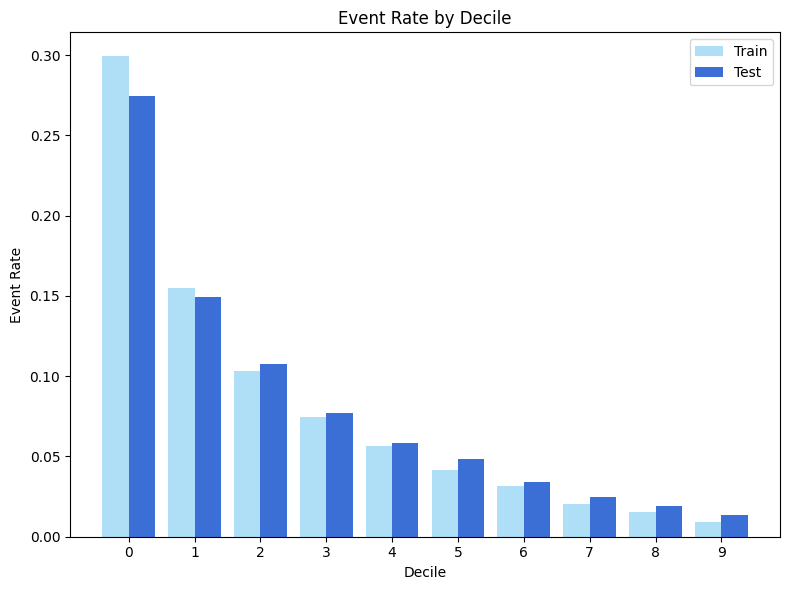

In [25]:
N_DECIS = 10

def calcular_decis(score, y_true, n_decis=10):
    df = pd.DataFrame({
        'score': score,
        'target': np.asarray(y_true)
    })

    df['decil'] = pd.qcut(df['score'], q=n_decis, labels=False, duplicates='drop')

    return (
        df.groupby('decil')['target']
        .mean()
        .reindex(range(n_decis))
    )


score_train = (1 - y_prob_treino_optuna) * 1000
score_test  = (1 - y_prob_teste_optuna) * 1000

event_rate_train = calcular_decis(score_train, y_train, N_DECIS)
event_rate_test  = calcular_decis(score_test, y_test, N_DECIS)

# Gráfico de barras agrupadas

x = np.arange(N_DECIS)
largura = 0.4

plt.figure(figsize=(8, 6))
plt.bar(x - largura/2, event_rate_train.values, width=largura, label='Train', color='#AEDFF7')
plt.bar(x + largura/2, event_rate_test.values,  width=largura, label='Test',  color='#3B6FD6')

plt.xlabel('Decile')
plt.ylabel('Event Rate')
plt.title('Event Rate by Decile')
plt.xticks(x, [str(i) for i in range(N_DECIS)])
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
def calcular_tabela_decis(y_prob, y_true, n_decis):
    """Gera tabela de decis com taxa de maus e taxa de maus acumulada.
    Decil 0 = maior risco (maior probabilidade prevista), Decil 9 = menor risco."""

    df = pd.DataFrame({
        'prob': y_prob,
        'target': np.asarray(y_true)
    })

    # qcut em -prob: decil 0 fica com as probabilidades mais altas (maior risco)
    df['decil'] = pd.qcut(-df['prob'], q=n_decis, labels=False, duplicates='drop')
    df['score'] = np.round((1 - df['prob']) * 1000, 0).astype(int)

    tabela = (
        df.groupby('decil')
        .agg(
            qtd_clientes    = ('target', 'count'),
            qtd_maus        = ('target', 'sum'),
            max_score       = ('score', 'max')
        )
        .reindex(range(n_decis))  # garante que todos os decis 0-9 apareçam
        .reset_index()
    )

    #tabela['taxa_maus'] = (tabela['qtd_maus'] / tabela['qtd_clientes'] * 100).round(2)
    #tabela['taxa_maus_acumulada'] = (tabela['qtd_maus'].cumsum() / tabela['qtd_maus'].sum() * 100).round(2)

    return tabela


# Comparação do treino e  Teste

tabela_treino = calcular_tabela_decis(y_prob_treino_optuna, y_train, n_decis=N_DECIS)
tabela_treino['split'] = 'Treino'

tabela_teste = calcular_tabela_decis(y_prob_teste_optuna, y_test, n_decis=N_DECIS)
tabela_teste['split'] = 'Teste'


df_decis_completo = pd.concat([tabela_treino, tabela_teste], ignore_index=True)
df_decis_completo = df_decis_completo[['split', 'decil', 'qtd_clientes', 'qtd_maus']]

display(tabela_treino)
display(tabela_teste)

,decil,qtd_clientes,qtd_maus,max_score,split
0,0,21526,6441,818,Treino
1,1,21526,3334,881,Treino
2,2,21525,2226,913,Treino
3,3,21526,1603,933,Treino
4,4,21526,1221,948,Treino
5,5,21525,895,959,Treino
6,6,21526,684,968,Treino
7,7,21525,445,976,Treino
8,8,21526,334,983,Treino
9,9,21526,194,999,Treino


,decil,qtd_clientes,qtd_maus,max_score,split
0,0,9226,2530,820,Teste
1,1,9225,1378,881,Teste
2,2,9225,993,913,Teste
3,3,9226,713,933,Teste
4,4,9225,538,948,Teste
5,5,9225,449,959,Teste
6,6,9226,313,968,Teste
7,7,9225,230,976,Teste
8,8,9225,178,983,Teste
9,9,9226,126,999,Teste
